In [1]:
import os
import sys 
from pyprojroot import here
sys.path.insert(0, str(here()))
from os.path import exists

import geopandas as gpd
from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data
from laos_gggi.data_functions.disaster_point_data import (load_disaster_point_data, 
                    load_synthetic_non_disaster_points, load_grid_point_data, load_non_disaster_grid)

from laos_gggi.plotting import configure_plot_style
from laos_gggi.statistics import get_distance_to_rivers, prediction_to_gpd_df , set_plotting_data, add_data, add_country_effect
from laos_gggi.data_functions.combine_data import load_all_data
from pymc.model.transform.optimization import freeze_dims_and_data

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr
import arviz as az
import scipy
import nutpie
import pathlib
import pickle
import wbdata
import datetime

import pymc as pm
import pytensor.tensor as pt
from laos_gggi.sample import sample_or_load


from laos_gggi.transformers import Standardize
from laos_gggi.data_functions.world_bank_data_loader import load_wb_data

configure_plot_style()

# Load and prepare data

In [2]:
# Load time series predictions
# predictions = (pd.read_csv(here('data/CRIforecast.csv'))
#                [['dev_ocean_temp', 'precip_deviation', 'co2', 'gdp_per_cap','Population' , 'time']]
#                .rename(columns = {"time": "Start_Year"}))

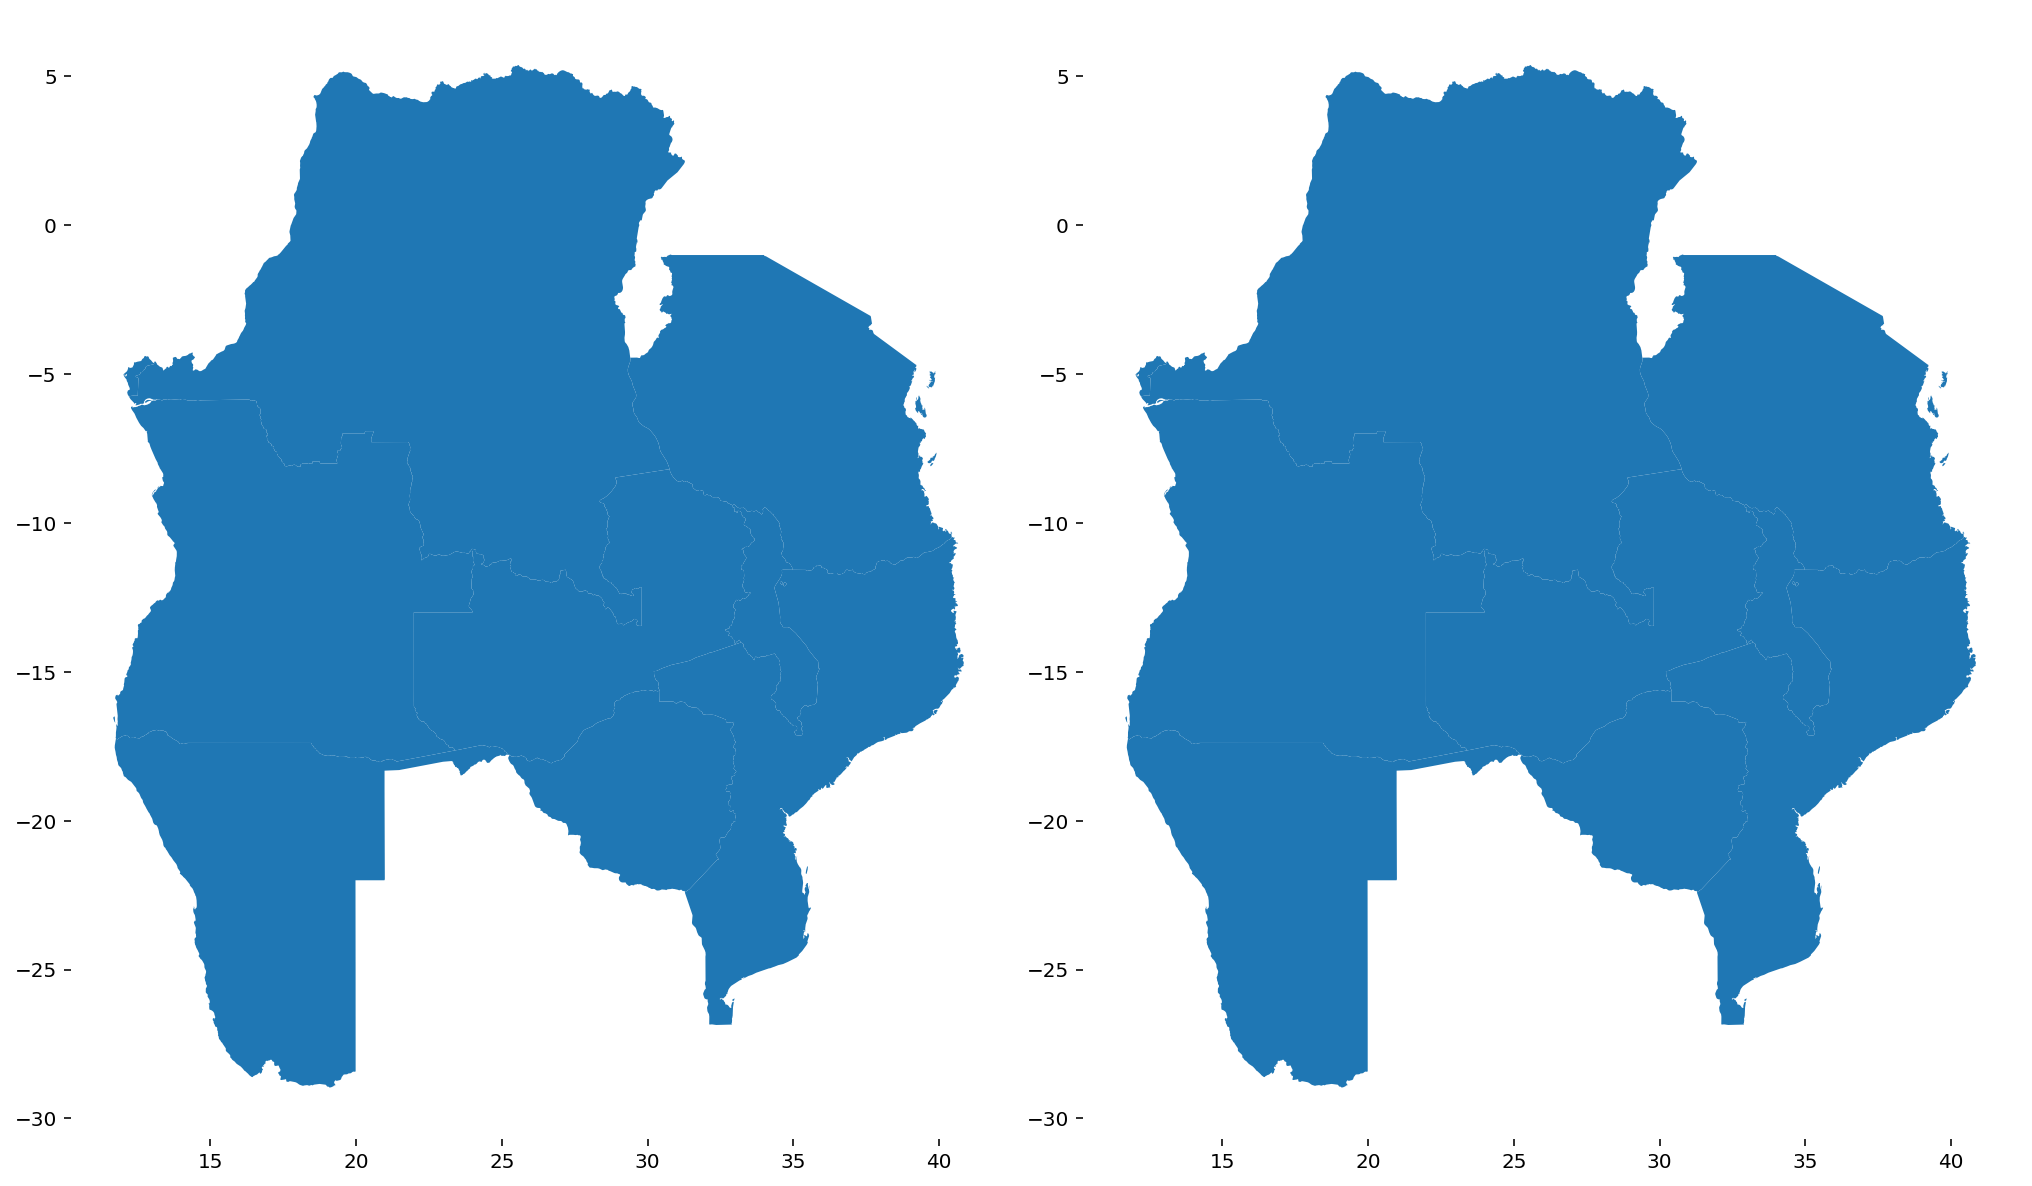

In [3]:
country_iso = "ZMB"
world = load_shapefile('world')
disasters = load_disaster_point_data()


region_name = 'zambia_neigh'
country_name = 'zambia'

# Select SA shape
region_list = [
    "ZMB",  # Zambia
    "AGO",  # Angola
    "COD",  # Democratic Republic of the Congo
    "TZA",  # Tanzania
    "MWI",  # Malawi
    "MOZ",  # Mozambique
    "ZWE",  # Zimbabwe
    "NAM",  # Namibia
]

# Define maps
region_map = world.query('ISO_A3 in @region_list')

# threshold_latitude = 6

# Explode MultiPolygons into separate geometries
# region_map_exploded = region_map.explode(index_parts=False)

# # Filter out geometries south of the threshold latitude
# region_map_filtered = region_map_exploded[
#     region_map_exploded.geometry.apply(lambda geom: geom.bounds[1] > threshold_latitude)
# ]


# Optional: Dissolve back to countries if needed
# region_map_filtered = region_map_filtered.dissolve(by='ISO_A3')
region_map_filtered = region_map.copy()


# Plot the result
fig, ax = plt.subplots(1,2, figsize=(14, 9), dpi=144)

region_map.plot(ax = ax[0])
region_map_filtered.plot(ax = ax[1])

region_map = region_map_filtered.rename(columns = {"lon":"long"})

country_map = region_map.query('ISO_A3 == @country_iso')

In [4]:
# Create prediction grids
region_point_grid = load_grid_point_data(region='custom',
                                     grid_size=400, 
                                     force_reload = False,
                                     iso_list=region_list,
                                    file_reg_name = "zambia_neigh_medium", 
                                     altered_shape_file = region_map.rename(columns = {"lon":"long"}),  include_medium_rivers= False)

country_point_grid = load_grid_point_data( region='custom',
                                       grid_size=400, 
                                         iso_list=['ZMB'], 
                                       force_reload = False,
                                     file_reg_name='zambia_medium',
                                      altered_shape_file = country_map.rename(columns = {"lon":"long"}), include_medium_rivers= False)

Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\shapefiles\zambia_neigh_medium_points_400.shp\zambia_neigh_medium_points_400.shp.shp
Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\shapefiles\zambia_medium_points_400.shp\zambia_medium_points_400.shp.shp


In [5]:
all_data = load_all_data()
panel_data  = all_data["df_panel"][['population_density', 'gdp_per_cap', 'Population', 'precip',]]
co2 = all_data["df_time_series"]["co2"]

In [6]:
########## disasters ##########
disasters = load_disaster_point_data()
#Delimiting data set to hydrometereological disasters
hydro_met_list = ['Hydrological', 'Meteorological']
hydrometereological_disasters = ['Flood', 'Storm', 'Mass movement (wet)']

disasters = disasters.rename(columns ={'Disaster Subgroup': 'subgroup'}).query('subgroup in @hydro_met_list')

disasters = disasters.rename(columns ={'Disaster Type': 'disaster_type'}).query('disaster_type in @hydrometereological_disasters')

########## non-disasters ##########
not_disasters = load_synthetic_non_disaster_points(by='country',
                                                       multiplier=15,
                                                       countries = region_list , list_name = 'zambia_neigh'
                                                    )

merged_df = pd.concat([not_disasters.assign(is_disaster = 0), 
                       disasters.reset_index().assign(is_disaster=1)], 
                      ignore_index= True)

# Adjust date format
merged_df["Start_Year"] = pd.to_datetime(merged_df["Start_Year"])

Loading data found at C:\Users\camil\Documents\Servicios\OCDE-GGI\laos-climate-change\data\synthetic_non_disasters_country_times_15_zambia_neigh_.csv


In [7]:
from statsmodels.tsa.seasonal import STL

precipitation = all_data["gpcc"]
precip_deviation = precipitation.groupby('ISO').transform(lambda x: x - x.iloc[:30].mean()).rename(columns={'precip':'precip_deviation'})

df_clim = all_data["df_time_series"][["co2", "Temp", "precip"]].iloc[1:-1].dropna(subset=['Temp'])
trend =  STL(pd.DataFrame(df_clim["Temp"].dropna()), period=3).fit().trend
dev_from_trend_ocean_temp = (df_clim['Temp'] - trend).to_frame(name='dev_ocean_temp')

In [8]:
from functools import reduce
df = reduce(lambda l, r: pd.merge(l, r, left_on=['ISO', 'Start_Year'], right_index=True, how='left'), [merged_df, panel_data, precip_deviation])
df = reduce(lambda l, r: pd.merge(l, r , left_on=['Start_Year'], right_index=True, how='left'), [df, co2, dev_from_trend_ocean_temp])

In [9]:
#Creating log variables
log_list = ["distance_to_river", "distance_to_coastline", "Total_Affected", "Total_Damage_Adjusted", "population_density",
            "gdp_per_cap"]
for y in log_list:
    df[f"log_{y}"] = np.log(df[y])



C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
#Delimiting data set
columns_to_use = ['ISO', 'Start_Year', "is_disaster", 'distance_to_river', 'distance_to_coastline',
               "Population", "co2", "precip_deviation", "dev_ocean_temp", "lat", "long" , "geometry", ]

features = ['log_distance_to_river', 'log_distance_to_coastline',
             "Population", "co2", "precip_deviation", "dev_ocean_temp", 'log_population_density',
             'log_gdp_per_cap', ]

model_df = df[ list( set( columns_to_use).union(set(features)) )].dropna()

# Exclude points outside general boundaries
# model_df = model_df.query('long < -75 & lat >7')


In [11]:
# Define list of features standardized
features_stand = []
for feature in features:
    features_stand.append(feature + "__standardized" )

time_varying_features = ['Population','co2','precip_deviation','dev_ocean_temp','log_population_density','log_gdp_per_cap',]
time_varying_features_stand = []

for feature in time_varying_features:
    time_varying_features_stand.append(feature + "__standardized")

### Create region and country data sets

In [12]:
#Create the geodata set for sea disasters
region_disasters = model_df.query('ISO in @region_list & is_disaster == 1')

region_disasters_geo = gpd.GeoDataFrame(
                region_disasters,
    geometry=gpd.points_from_xy(region_disasters["long"], region_disasters["lat"]), crs="EPSG:4326"
            )

# Create the geodata set for CR disasters
country_disasters = model_df.query('ISO == @country_iso & is_disaster == 1')

country_disasters_geo = gpd.GeoDataFrame(
                country_disasters,
    geometry=gpd.points_from_xy(country_disasters["long"], country_disasters["lat"]), crs="EPSG:4326"
            )

In [13]:
# Define dfs
region_df = model_df.query('ISO in @region_list')
country_df = model_df.query('ISO == @country_iso')

#Tranform dfs to geopandas df
region_df = gpd.GeoDataFrame(region_df,  geometry=gpd.points_from_xy(region_df["long"],
                                region_df["lat"]),crs="EPSG:4326")

country_df = gpd.GeoDataFrame(country_df,  geometry=gpd.points_from_xy(country_df["long"],
                                country_df["lat"]),crs="EPSG:4326")

In [14]:
country_year_data ={}
country_year_df = {}
result_yearsdata = [ 2018]

for year in result_yearsdata:
    country_year_data[year] = {}
    country_year_df[year] = pd.DataFrame()
    for country in region_list:
        country_year_data[year][country] = region_df.query('Start_Year == "2020-01-01" & ISO == @country').iloc[[0]][time_varying_features + ["ISO" ]]
        country_year_df[year] = pd.concat([country_year_df[year], country_year_data[year][country] ])  

C:\Users\camil\AppData\Local\Temp\ipykernel_16300\2752471704.py:9: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  country_year_data[year][country] = region_df.query('Start_Year == "2020-01-01" & ISO == @country').iloc[[0]][time_varying_features + ["ISO" ]]
C:\Users\camil\AppData\Local\Temp\ipykernel_16300\2752471704.py:9: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  country_year_data[year][country] = region_df.query('Start_Year == "2020-01-01" & ISO == @country').iloc[[0]][time_varying_features + ["ISO" ]]
C:\Users\camil\AppData\Local\Temp\ipykernel_16300\2752471704.py:9: Futur

In [15]:
# Merge points with world ISO
region_point_grid_extended = {}
region_point_grid_extended_df = gpd.sjoin(region_point_grid, region_map, how="left", )
region_point_grid_extended_df = region_point_grid_extended_df.rename(columns = {"lon": "long"})

# Creating the country_point_grid_extended
country_point_grid["ISO"] = country_iso
country_point_grid_extended = {}
country_point_grid_extended_df = gpd.sjoin(country_point_grid, country_map, how="left", )
country_point_grid_extended_df = country_point_grid_extended_df.rename(columns = {"lon": "long"})

In [16]:
for year in result_yearsdata:
    # Region loop
    region_point_grid_extended[year] = pd.merge(region_point_grid_extended_df, country_year_df[year], how = "left", left_on= "ISO_A3", right_on="ISO" ) 

    #Country loop
    country_point_grid_extended[year] = pd.merge(country_point_grid_extended_df,  country_year_df[year], how = "left", left_on= "ISO", right_on="ISO" ) 

In [17]:
# Standardize SEA data
transformer_stand_ =  Standardize().fit(region_df)
region_df_stand = transformer_stand_.transform(region_df)
country_df_stand = transformer_stand_.transform(country_df)

for year in result_yearsdata:
    region_point_grid_extended[year] = transformer_stand_.transform(region_point_grid_extended[year]) 
    country_point_grid_extended[year] = transformer_stand_.transform(country_point_grid_extended[year])

In [18]:
# grid cols
grid_cols = ['ISO_A3', 'long', 'lat', 'log_distance_to_river','log_distance_to_coastline', 
 'geometry', ]

In [19]:
# # Save files
# region_point_grid_extended["2020"].to_csv(f"data/{region_name}_point_grid.csv")
# country_point_grid_extended["2020"].to_csv(f"data/{country_name}_point_grid.csv")
# region_df.to_csv(f"data/{region_name}_df.csv")
# country_df.to_csv(f"data/{country_name}_df.csv")
# region_df_stand.to_csv(f"data/{region_name}_df_stand.csv")
# country_df_stand.to_csv(f"data/{country_name}_df_stand.csv")  

In [20]:
result_years = [2018]
prediction_years = [2030, 2045, 2055]

In [21]:
# Load country area
indicator = "AG.LND.TOTL.K2"
country_area = wbdata.get_data(indicator, country=country_iso, date=datetime.datetime(2020, 1, 1))[0]['value']

In [22]:
# Add prediction data
# predictions['ISO'] = country_iso

# # Load IPCC data
# ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

# # Create population density
# # predictions["population_density"] = predictions["Population"] / 51100 * 1e6 # Laos area in squared km hardcoded
# predictions['Population'] = predictions['Population'] *1e6
# predictions["population_density"] = predictions["Population"] / country_area
# predictions['year'] = pd.to_datetime(predictions['Start_Year']).dt.year

# # Calculate logs
# predictions["log_population_density"] = np.log(predictions["population_density"])
# predictions["log_gdp_per_cap"] = np.log(predictions["gdp_per_cap"])


In [23]:
# for year in prediction_years:
#     country_point_grid_extended[year] = pd.merge(country_point_grid_extended_df, predictions.query('year == @year'), how = "left", left_on= "ISO", right_on="ISO" )
#     country_point_grid_extended[year] = transformer_stand_.transform(country_point_grid_extended[year])
    
#     region_point_grid_extended[year] = pd.merge(region_point_grid_extended_df, predictions.query('year == @year'), how = "left", left_on= "ISO_A3", right_on="ISO" ) 
#     region_point_grid_extended[year] = transformer_stand_.transform(region_point_grid_extended[year]) 

## Maps

[]

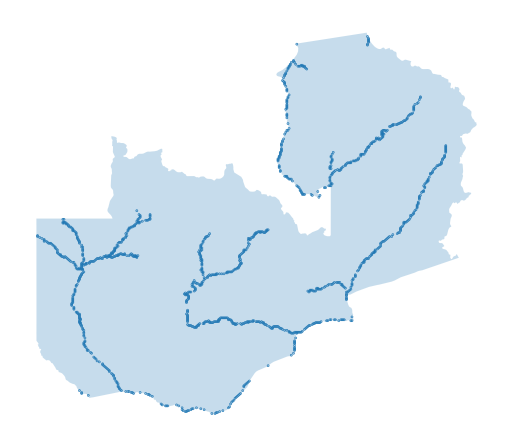

In [24]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=144)
country_map.plot(facecolor='tab:blue', alpha=0.25, ax=ax)
country_point_grid_extended[2018].query('distance_to_river < 1000').plot('is_island', ax=ax , markersize=0.1)
ax.set_xticks([])
ax.set_yticks([])

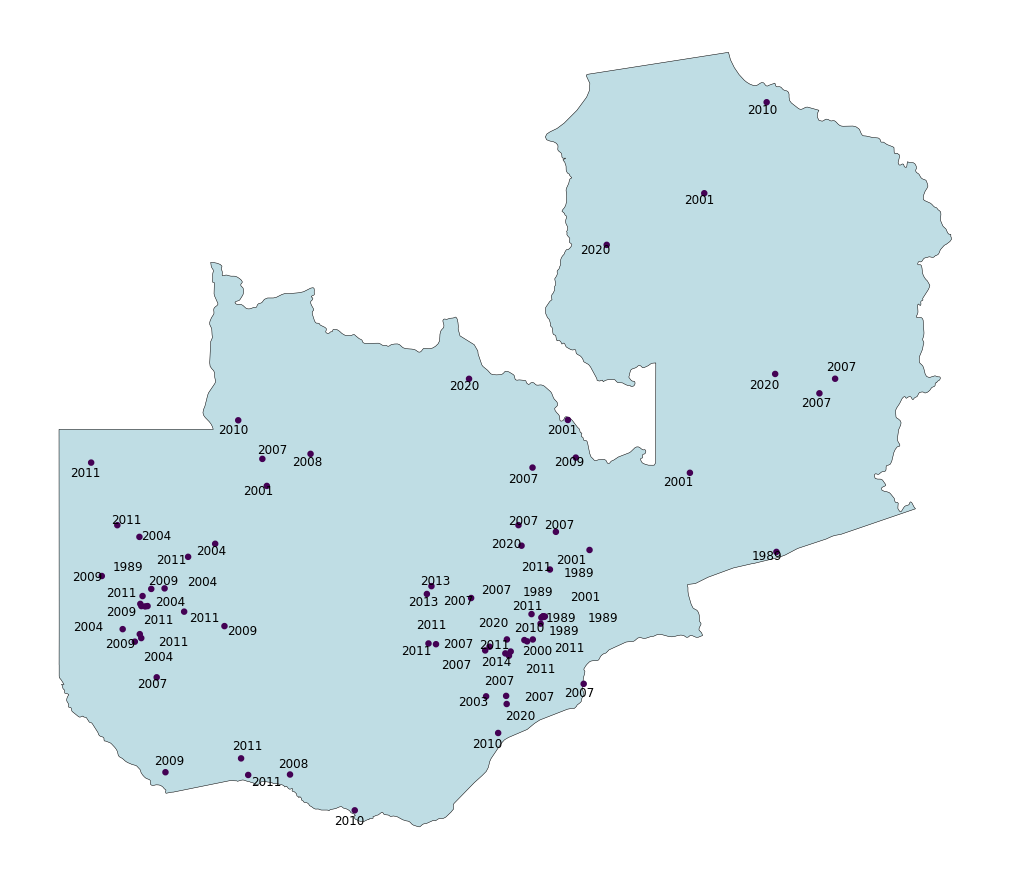

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(14, 6), dpi=144)

# Plot the map and disaster locations
country_map.plot(facecolor='#007896', alpha=0.25, ax=ax)
country_map.plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
country_disasters_geo.query('is_disaster == 1').plot('is_disaster', ax=ax,  markersize=5)

texts = []
for idx, row in country_disasters_geo.query('is_disaster == 1').iterrows():
    # Compute an angle for rotation (in radians)
    angle = np.random.uniform(0, 2 * np.pi)  # Random angle between 0 and 360 degrees

    # Define the label distance from the point
    r = 0.05  # Adjust this to control the distance from the point

    # Convert polar coordinates to Cartesian (offset x, y)
    dx = r * np.cos(angle)
    dy = r * np.sin(angle)

    texts.append(ax.annotate(row['Start_Year'].year, 
                             xy=(row.geometry.x, row.geometry.y),  # Point location
                             xytext=(row.geometry.x + dx, row.geometry.y + dy),  # Rotated position
                             textcoords="data",
                             fontsize=6, color='black',
                             ha='center', va='center'))  # Keep text aligned

# Adjust text positions slightly to avoid overlapping
adjust_text(texts, ax=ax, only_move={'text': 'xy'}, expand_text=(1.1, 1.1));
ax.set_xticks([])
ax.set_yticks([]);
# fig.savefig(here('notebooks/final_paper/figures_and_plots/eda') / 'year_event_map_cr.png', format = 'png', bbox_inches='tight');

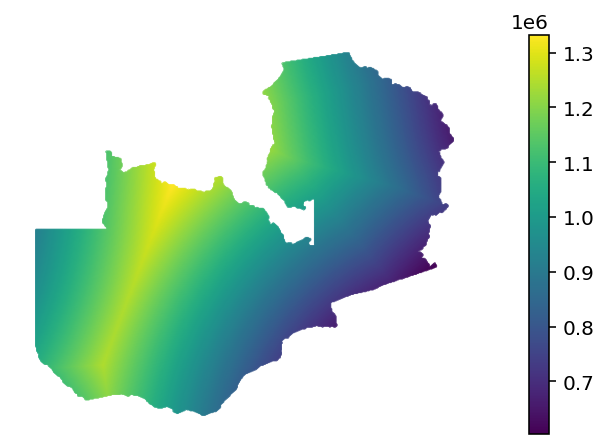

In [26]:
fig, ax = plt.subplots(figsize=(6, 3), dpi=144)
country_map.plot(facecolor='tab:blue', alpha=0.25, ax=ax)
country_point_grid_extended[2018].plot('distance_to_coastline', ax=ax , markersize=0.1, legend = True)
ax.set_xticks([])
ax.set_yticks([]);



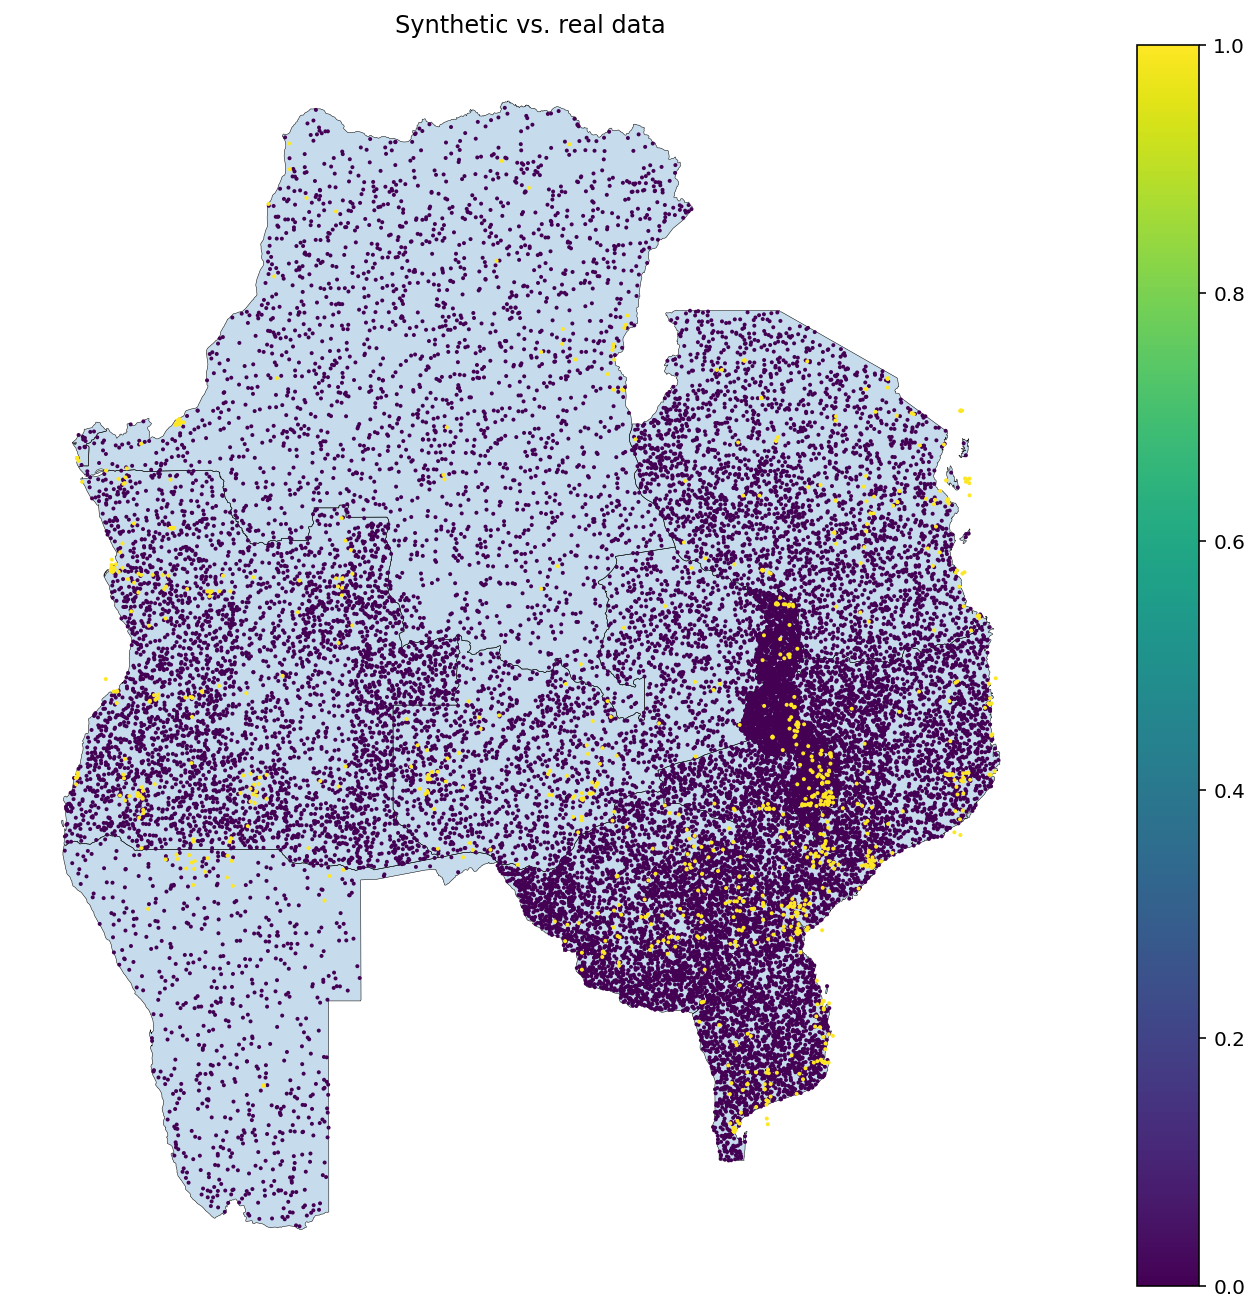

In [27]:
fig, ax = plt.subplots(figsize=(14, 9), dpi=144)
region_map.plot(facecolor='tab:blue', alpha=0.25, ax=ax)
region_map.plot(facecolor='none', edgecolor='k', lw=0.25, ax=ax)
# rivers.plot(edgecolor='dodgerblue', lw=0.5, ax=ax)

region_df.plot('is_disaster', 
                                      markersize=1, 
                                      ax=ax, 
                                      legend=True, 
                                      # categorical=True,
                                      cmap='viridis')
ax.axis('off')
plt.title("Synthetic vs. real data")
plt.show()

# HSGP model

In [28]:
#Define cooords
is_disaster_idx , is_disaster = pd.factorize(region_df["is_disaster"])
ISO_idx, ISO = pd.factorize(region_df["ISO"]) 
obs_idx = region_df.index
gp_features = ["lat", "long"]

#Creating idx
xr_idx = xr.Coordinates.from_pandas_multiindex(region_df.set_index(['ISO', 'Start_Year']).index, 'obs_idx')

#Set coords
coords_sea = {"is_disaster" : is_disaster,
        "obs_idx": obs_idx,
        "ISO": ISO,
        "feature": features_stand,
        "gp_feature":gp_features }

In [29]:
# with pm.Model(coords=coords_sea) as hsgp_model:
#     #Declare data
#     X, Y= add_data(features= features_stand ,  target = "is_disaster", df =  region_df_stand, )

#     # HSGP process
#     X_gp = pm.Data("X_gp", region_df_stand[["lat", "long"]])

#     # Prior on the HSGP
#     eta = pm.Exponential("eta", scale=2)
#     ell_params = pm.find_constrained_prior(
#         pm.Lognormal, lower=0.5, upper=10.0, mass=0.95, init_guess={"mu": 1.0, "sigma": 1.0}
#     )
#     ell = pm.Lognormal("ell", **ell_params, dims=["gp_feature"])
#     cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)

#     m0, m1, c = 35, 35, 1.5
#     gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)
    
#     phi, sqrt_psd = gp.prior_linearized(X=X_gp)

#     basis_coeffs = pm.Normal("basis_coeffs", size=gp.n_basis_vectors)
#     HSGP_component = pm.Deterministic("HSGP_component", phi @ (basis_coeffs * sqrt_psd))

#     p = HSGP_component
    
#     y_hat = pm.Bernoulli('y_hat', logit_p = p, observed=Y, dims='obs_idx')

In [30]:
# # Sample the model
# model_path = f"idata/hsgp_{country_name}.idata"
# if exists(model_path):
#     hsgp_model_idata = az.from_netcdf(model_path)

# else:
#     compiled_model = nutpie.compile_pymc_model(freeze_dims_and_data(hsgp_model), backend="jax", gradient_backend='jax')
#     hsgp_model_idata = nutpie.sample(compiled_model)
#     #Save the idata
#     az.to_netcdf(data = hsgp_model_idata, filename= pathlib.Path(model_path))

### CA predictions

In [31]:
# # We sample the predictions
# file_name = f'idata/hsgp_pred_{region_name}.pkl'
# if exists(file_name):
#     with open(file_name, 'rb') as f:
#         hggp_ca_pred_idata = pickle.load(f)

# else:
#     with hsgp_model.copy() as temp_model:
#         pm.set_data({"X_gp": region_point_grid.rename(columns  = {'lon':'long' } )[["lat", "long"]],
#                      "Y": np.full(region_df_stand.shape[0], 0 ),
#                     },
#                 coords= {"obs_idx": region_df_stand.index.values } 
#                )
    
#         HSGP_invlogit = pm.Deterministic('HSGP_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
    
    
    
#     with freeze_dims_and_data(temp_model):
#         hggp_ca_pred_idata = pm.sample_posterior_predictive(hsgp_model_idata, var_names=["HSGP_invlogit","HSGP_component"], 
#                                                              compile_kwargs= {"mode" : "JAX" })
#     with open(file_name, 'wb') as f:
#         pickle.dump(hggp_ca_pred_idata, f)

In [32]:
# # Create the geopandas version of the predictions
# region_hsgp_pred = prediction_to_gpd_df(prediction_idata = hggp_ca_pred_idata , 
#                      variables = ["HSGP_invlogit", "HSGP_component"] , 
#                      points = region_point_grid.rename(columns  = {'lon':'long' } ) )

# df_hsgp=  region_hsgp_pred['HSGP_invlogit'].assign(norm_prob =  
#                                                    (region_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'] * 100 
#                                                     /  region_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'].sum()) )


In [33]:
# # Plot the predictions
# fig, ax = plt.subplots(figsize=(8, 5), dpi= 144 )
# df_hsgp.plot("norm_prob",legend=True, ax=ax,markersize =1 , vmax = 0.01)
# region_disasters_geo.plot(ax=ax, alpha = 0.3, c = "red",markersize =0.7, )

# ax.set_xticks([])
# ax.set_yticks([]);

# # fig.savefig(here('notebooks/final_paper/figures_and_plots/results') / 'hsgp_central_america.png', format = 'png', bbox_inches='tight');

### CR prediction

In [34]:
# file_name = f'idata/hsgp_pred_cr.pkl'
# if exists(file_name):
#     with open(file_name, 'rb') as f:
#         country_hsgp_pred = pickle.load(f)

# else:
#     with hsgp_model.copy() as temp_model:
#         pm.set_data({"X_gp": country_point_grid.rename(columns  = {'lon':'long' } ) [["lat", "long"]],
#                      "X": country_point_grid_extended['2010'][features_stand],
#                      "Y": np.full(country_point_grid.shape[0], 0 ),
#                     },
#                 coords= {"obs_idx": np.arange(country_point_grid.shape[0]) } 
#                )
    
#         HSGP_invlogit = pm.Deterministic('HSGP_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
    
    
    
#     with freeze_dims_and_data(temp_model):
#         country_hsgp_pred = pm.sample_posterior_predictive(hsgp_model_idata, var_names=["HSGP_invlogit","HSGP_component"], 
#                                                              compile_kwargs= {"mode" : "JAX" })
#     with open(file_name, 'wb') as f:
#         pickle.dump(country_hsgp_pred, f)

In [35]:
# # Create the geopandas version of the predictions
# country_hsgp_pred = prediction_to_gpd_df(prediction_idata = country_hsgp_pred , 
#                      variables = ["HSGP_invlogit", "HSGP_component"] , 
#                      points = country_point_grid.rename(columns  = {'lon':'long' } ) [["lat", "long"]])

# df_country=  country_hsgp_pred['HSGP_invlogit'].assign(norm_prob =  
#                                                    (country_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'] * 100 
#                                                     /  country_hsgp_pred['HSGP_invlogit']['HSGP_invlogit'].sum()) )

In [36]:
# # Plot the predictions
# fig, ax = plt.subplots(figsize=(5, 5), dpi= 144 )
# df_country.plot("norm_prob",legend=True, ax=ax,markersize =1,vmax = 0.01  )
# country_disasters_geo.query('ISO == @country_iso').plot(ax=ax, alpha = 0.3, c = "red",markersize =0.7, )

# ax.set_xticks([])
# ax.set_yticks([]);

# # fig.savefig(here('notebooks/final_paper/figures_and_plots/results') / 'hsgp_cr.png', format = 'png', bbox_inches='tight');

#  Full model

In [37]:
mu_vec = np.zeros(len(features_stand))
mu_vec[0] = -1


with pm.Model(coords=coords_sea) as model_region_full:
    #Declare data
    X, Y= add_data(features= features_stand ,  target = "is_disaster", df =  region_df_stand, )
    ISO_idx_pt = pm.Data("ISO_idx_pt", ISO_idx, dims= ["obs_idx"] )
    
    # # #Country effect
    country_effect = pm.Normal("country_effect", mu = 0, sigma =1, dims = ["ISO"])

    # #Betas
    beta_sigma = [0.1] * 8
    beta = pm.Normal("beta", mu = mu_vec, sigma = beta_sigma, dims = ["feature"])

    # HSGP process
    X_gp = pm.Data("X_gp", region_df[["lat", "long"]])

    # Prior on the HSGP
    eta = pm.Exponential("eta", scale=2)
    ell_params = pm.find_constrained_prior(
        pm.Lognormal, lower=0.5, upper=10.0, mass=0.95, init_guess={"mu": 1.0, "sigma": 1.0}
    )
    ell = pm.Lognormal("ell", **ell_params, dims=["gp_feature"])
    cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)

    m0, m1, c = 35, 35, 1.5
    gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)

    phi, sqrt_psd = gp.prior_linearized(X=X_gp)

    basis_coeffs = pm.Normal("basis_coeffs", size=gp.n_basis_vectors)
    HSGP_component = pm.Deterministic("HSGP_component", phi @ (basis_coeffs * sqrt_psd),dims= ["obs_idx"])


    #Model mu
    mu = pm.Deterministic("mu", 
                          country_effect[ISO_idx_pt] + 
                          X@beta +
                          HSGP_component , dims= ["obs_idx"] )
    

    # Now define the observed variable separately
    y_hat = pm.Bernoulli('y_hat', logit_p=mu, observed=Y, dims=['obs_idx'])

C:\Users\camil\AppData\Local\Temp\ipykernel_16300\628634323.py:22: FutureWarning: find_constrained_prior is deprecated and will be removed in a future version. Please use maxent function from PreliZ. https://preliz.readthedocs.io/en/latest/api_reference.html#preliz.unidimensional.maxent
  ell_params = pm.find_constrained_prior(


In [41]:
idat_path = f'idata/full_{region_name}_400.idata'
if exists(idat_path):
    model_region_full_idata = az.from_netcdf(idat_path)

else:
    compiled_model = nutpie.compile_pymc_model(freeze_dims_and_data(model_region_full), backend="jax", gradient_backend='jax')
    model_region_full_idata = nutpie.sample(compiled_model, chains = 8, draws = 1000, target_accept = 0.9)
    # Save the idata
    az.to_netcdf(data=model_region_full_idata, filename=pathlib.Path(idat_path))

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.08,63
,1400,0,0.08,63
,1400,0,0.08,63
,1400,0,0.08,63
,1400,0,0.08,63
,1400,0,0.09,63
,1400,0,0.07,63
,1400,0,0.09,63


In [42]:
vars_ = ['ell_log__', 'eta', 'eta_log__','beta', 'country_effect']
full_sum = az.summary(model_region_full_idata, var_names = vars_ )
full_sum[['mean', 'sd', 'ess_bulk', 'ess_tail', 'r_hat']]

,mean,sd,ess_bulk,ess_tail,r_hat
ell_log__[0],-0.39,0.40,192.00,294.00,1.05
ell_log__[1],0.06,0.22,169.00,261.00,1.05
eta,2.58,0.38,239.00,311.00,1.04
eta_log__,0.94,0.14,239.00,311.00,1.04
beta[log_distance_to_river__standardized],-0.30,0.04,14626.00,6338.00,1.00
beta[log_distance_to_coastline__standardized],-0.44,0.06,942.00,2045.00,1.01
beta[Population__standardized],0.11,0.07,6151.00,6078.00,1.00
beta[co2__standardized],0.59,0.05,5691.00,6074.00,1.00
beta[precip_deviation__standardized],0.28,0.03,18791.00,6007.00,1.00
beta[dev_ocean_temp__standardized],-0.09,0.04,19342.00,5798.00,1.00


### region predictions

Now we load the prediction of the frequency model to have the full event probability

In [43]:
# full model region predictions

# Rebuild ISO_idx_region

years_region =[2018]

geo_full_region_idata = {}
ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}

for year in years_region:
    file_name = f'idata/geo_full_{region_name}' +str(year) + '_400.pkl'
    ISO_idx_region=  region_point_grid_extended[year].ISO.map(ISO_to_idx.get)
    if exists(file_name):
        with open(file_name, 'rb') as f:
            geo_full_region_idata[year] = pickle.load(f)
    else:
        with model_region_full.copy() as temp_model:
            #Declare data
            pm.set_data({"X_gp":region_point_grid_extended[year][["lat", "long"]],
                         "Y": np.full(region_point_grid_extended[year].shape[0], 0 ),
                         "X": region_point_grid_extended[year][features_stand],
                         "ISO_idx_pt": ISO_idx_region
         
                    },
                coords= {"obs_idx": region_point_grid_extended[year].index.values } 
               )
        
            y_hat_invlogit = pm.Deterministic('y_hat_invlogit', pm.math.invlogit(temp_model["y_hat"] ))
    
            HSGP_component_invlogit = pm.Deterministic('HSGP_component_invlogit', pm.math.invlogit(temp_model["HSGP_component"] ))
        
        
        
        with freeze_dims_and_data(temp_model):
            geo_full_region_idata[year] = pm.sample_posterior_predictive(model_region_full_idata, var_names=["y_hat_invlogit","y_hat", "HSGP_component",
                                                                                                          "HSGP_component_invlogit",], 
                                                         )
        with open(file_name, 'wb') as f:
            pickle.dump(geo_full_region_idata[year], f)

Sampling: [y_hat]
INFO:pymc.sampling.forward:Sampling: [y_hat]


Output()

In [44]:
# Create the geopandas version of the predictions
model_region_full_predictions_geo = {}

for year in years_region:
    model_region_full_predictions_geo[year] = prediction_to_gpd_df(prediction_idata =geo_full_region_idata[year], 
                         variables = ["y_hat"  ] , 
                         points = region_point_grid_extended[year] )

In [45]:
# Normalize the results
df_ = {}
for year in years_region:
    df_[year]= model_region_full_predictions_geo[year]['y_hat'].assign(norm_prob =  
                                                   (model_region_full_predictions_geo[year]['y_hat']['y_hat'] * 100 
                                                    /  model_region_full_predictions_geo[year]['y_hat']['y_hat'].sum()) )

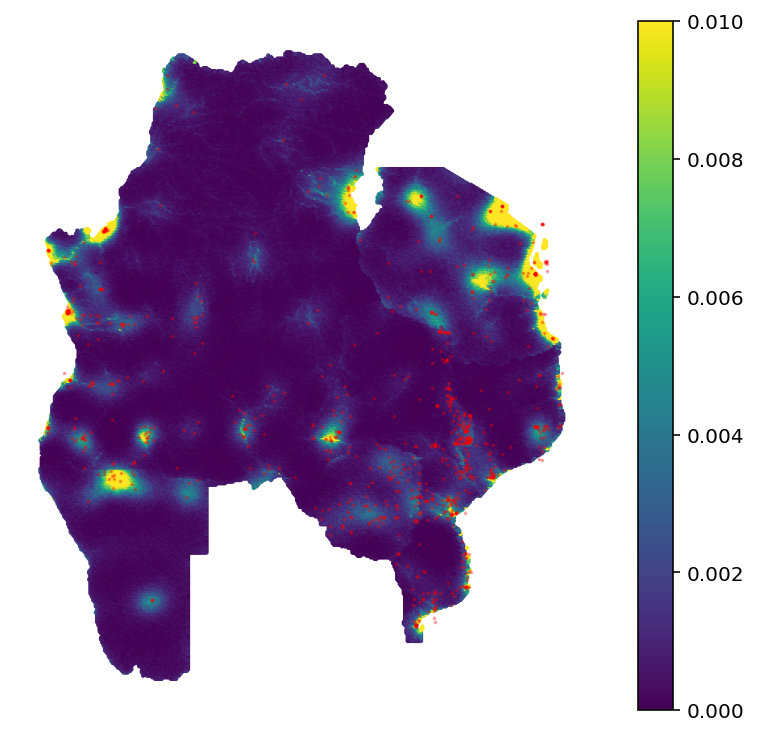

In [46]:
#Plot the predictions
fig, ax = plt.subplots(figsize=(8, 5), dpi= 144 )
df_[2018].plot("norm_prob",legend=True, ax=ax,markersize =1.5, vmax =  0.01  )
region_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =0.7, )
# plt.title("Event probability for Laos neighbors", );


ax.set_xticks([])
ax.set_yticks([]);
# fig.savefig("figures_and_plots/results/full_model_ca_2018.png");

### Country predictions

In [ ]:
result_years = [2018]
model_full_pred_country = {}

ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}

for year in result_years:
    # Rebuild ISO_idx_sea
    ISO_idx_country =  country_point_grid_extended[year].ISO.map(ISO_to_idx.get)
    
    file_name = 'idata/full_pred_cr_' + str(year) + '_distance_neg.pkl'
    if exists(file_name):
        with open(file_name, 'rb') as f:
            model_full_pred_country[year] = pickle.load(f)

    else:
        with model_region_full.copy() as temp_model:
            #Declare data
            pm.set_data({"X_gp": country_point_grid_extended[year][["lat", "long"]],
                         "Y": np.full(country_point_grid_extended[year].shape[0], 0 ),
                         "X": country_point_grid_extended[year][features_stand],
                         "ISO_idx_pt": ISO_idx_country
         
                    },
                coords= {"obs_idx": country_point_grid_extended[year].index.values } 
               )
        
            y_hat_invlogit = pm.Deterministic('y_hat_invlogit', pm.math.invlogit(temp_model["y_hat"] ))
    
            # River effect
            river_effect = pm.Deterministic('river_effect', temp_model["beta"][0] * country_point_grid_extended[year]['log_distance_to_river__standardized'])
            # Coast effect
            coast_effect = pm.Deterministic('coast_effect',  temp_model["beta"][1] * country_point_grid_extended[year]['log_distance_to_coastline__standardized'])
                                                    
        
        with freeze_dims_and_data(temp_model):
            model_full_pred_country[year] = pm.sample_posterior_predictive(
                model_region_full_idata, var_names=["y_hat_invlogit","HSGP_component", "y_hat", "river_effect", "coast_effect"], )
        with open(file_name, 'wb') as f:
            pickle.dump(model_full_pred_country[year], f)

Now we load the prediction of the frequency model to have the full event probability

In [ ]:
# # Load the posterior with event frequency predictions
# file_name = f'idata/idata_pred_full{country_name}.pkl'

# if exists(file_name):
#     with open(file_name, 'rb') as f:
#         idata_damage_curve_combined = pickle.load(f)

# idata_damage_curve_combined = idata_damage_curve_combined.posterior_predictive.sel(disaster = 'hydro', obs_iso = 'CRI')['y_hat_n_events'].mean(dim = ['chain', 'draw'])

In [ ]:
# Create the geopandas version of the predictions
model_full_pred_country_gpd = {}

for year in result_years:
    model_full_pred_country_gpd[year] = prediction_to_gpd_df(prediction_idata = model_full_pred_country[year] , 
                         variables = ['y_hat', "HSGP_component", "river_effect",'coast_effect'] , 
                         points = country_point_grid_extended[year] )

In [ ]:
# Normalized values
var_list = ['y_hat',]
for year in result_years:
    for var in var_list:
        model_full_pred_country_gpd[year][var] = model_full_pred_country_gpd[year][var].assign(norm = model_full_pred_country_gpd[year][var][var] *100 
                                                                / model_full_pred_country_gpd[year][var][var].sum(), )

In [ ]:
#Plot the predictions
fig, ax = plt.subplots(figsize=(5, 5), dpi= 144 )
model_full_pred_country_gpd[2018]['y_hat'].plot("norm",legend=True, ax=ax,markersize =1, vmax = 0.01,)
country_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =2, )
# plt.title("Event probability for Laos", )

ax.set_xticks([])
ax.set_yticks([])
# fig.savefig("figures_and_plots/results/full_model_cr_2018.png");

In [ ]:

# # Multiply by the frequency predictions
# for year in result_years:
#     freq_pred = idata_damage_curve_combined.sel(obs_year = pd.to_datetime(str(year))).values
    
#     model_full_pred_country_gpd[year]['y_hat'] = model_full_pred_country_gpd[year]['y_hat'].assign(
#         yhat_freq = model_full_pred_country_gpd[year]['y_hat']['norm'] *freq_pred , inplace =True)


In [ ]:
# We decompose further the effect for 2018
for var in ["HSGP_component", "river_effect",'coast_effect']:
    freq_pred = idata_damage_curve_combined.sel(obs_year = pd.to_datetime(str(year))).values
    model_full_pred_country_gpd[2018][var] = model_full_pred_country_gpd[2018][var].assign(norm = model_full_pred_country_gpd[2018][var][var] *100 
                                                            / model_full_pred_country_gpd[2018]['y_hat']['y_hat'].sum(), )
    
    model_full_pred_country_gpd[2018][var] = model_full_pred_country_gpd[2018][var].assign(
    propor_decomp = model_full_pred_country_gpd[2018][var]['norm'] *freq_pred , inplace =True)


In [ ]:
#Plot the predictions
fig, ax = plt.subplots(figsize=(5, 5), dpi= 144 )
model_full_pred_country_gpd[2018]['y_hat'].plot("norm",legend=True, ax=ax,markersize =1, vmax = 0.01,)
country_disasters_geo.plot(ax=ax, alpha = 0.3, c = "r", markersize =2, )
# plt.title("Event probability for Laos", )

ax.set_xticks([])
ax.set_yticks([])
# fig.savefig("figures_and_plots/results/full_model_cr_2018.png");

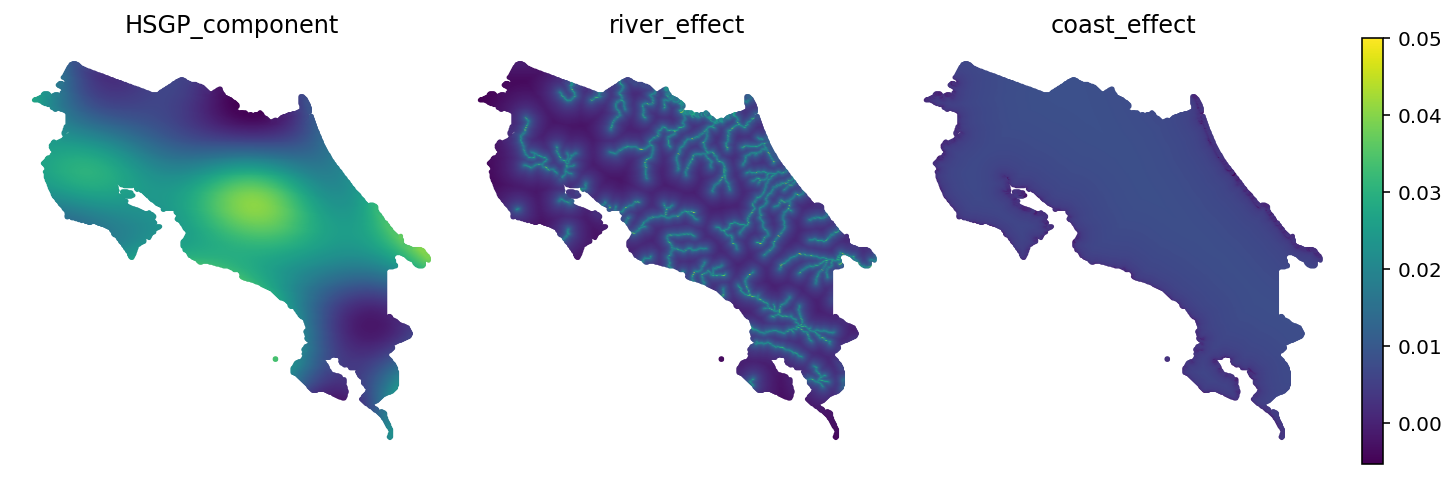

In [50]:
fig, axes = plt.subplots(1,3,figsize=(10, 6), dpi= 144 )

var_list = ["HSGP_component", "river_effect",'coast_effect']
legen_list = [False, False, True]

for var, n in zip(var_list, [0,1,2] ):
    model_full_pred_country_gpd[2018][var].plot('propor_decomp',legend= legen_list[n], ax = axes[n] 
                                                     ,markersize =1.5, vmax = 0.05, 
                                                legend_kwds={
                                                         "shrink": 0.5,    # scale down the colorbar (0.3–0.8 usually works well)
                                                         "aspect": 20,     # make it thinner
                                                }
                                               )
    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(var)
# fig.savefig("figures_and_plots/results/decomposed_effect_cr.png",  bbox_inches="tight",);

C:\Users\camil\AppData\Local\Temp\ipykernel_19672\3840774719.py:19: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(top=0.9, bottom=0.1, wspace=0.3, hspace=0.2)


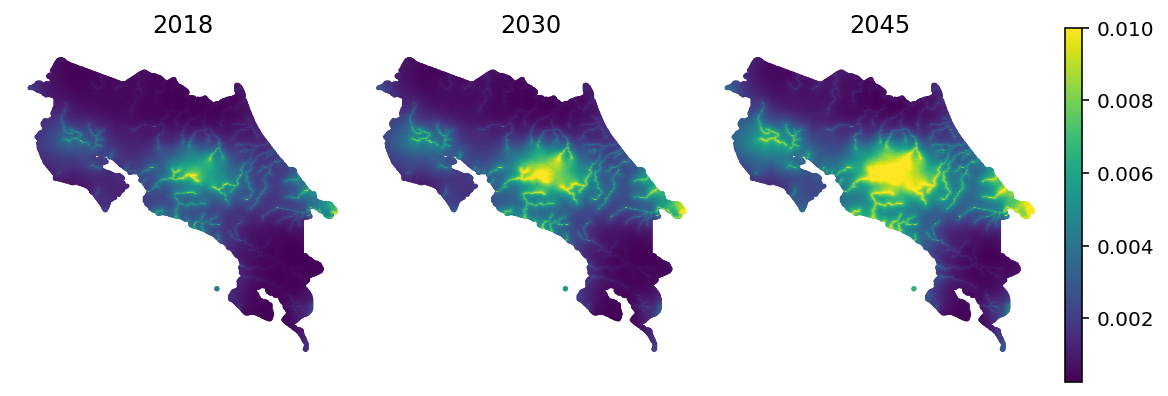

In [51]:
fig, axes = plt.subplots(1,3,figsize=(8, 5), dpi= 144 )
axes = axes.flatten()

years_plot=[ 2018, 2030, 2045]

legen_list = [ False, False, True]

for year, n in zip(years_plot, range(0,3) ):
    model_full_pred_country_gpd[year]['y_hat'].plot('yhat_freq' ,legend= legen_list[n], ax = axes[n] 
                                    ,markersize =1.5, vmax = 0.01 ,   legend_kwds={
        "shrink": 0.5,    # scale down the colorbar (0.3–0.8 usually works well)
        "aspect": 20,     # make it thinner
    })

    axes[n].set_xticks([])
    axes[n].set_yticks([])
    axes[n].set_title(year)
    
plt.subplots_adjust(top=0.9, bottom=0.1, wspace=0.3, hspace=0.2)
# fig.savefig("figures_and_plots/results/full_model_yearly_cr.png",     bbox_inches="tight",
#     dpi=144);

# CR location analysis

In [52]:
locs_a =pd.DataFrame( {
    "name": [
        "Desamparados (San José)", 
        "El Bambú (Filadelfia, Guanacaste)", 
        "Cariari (Pococí, Limón)"
    ],
    "lat": [9.88, 10.43866, 10.357],
    "long": [-84.05, -85.55528, -83.736]
})

In [53]:
# Obtain the city points in the predictions
dist_square = {}
best_loc_index = {} 
best_loc = {}
locations =locs_a['name']
df_a = model_full_pred_country_gpd[2018]['y_hat']

In [54]:
for location in locations:
    dist_square[location] = ((df_a["lat"] - locs_a.query('name ==@location')["lat"].values)**2 + (df_a["long"] - locs_a.query('name ==@location')["long"].values)**2)
    best_loc_index[location] =  dist_square[location].sort_values().head(1).index.values[0]
    best_loc[location] = df_a.loc[best_loc_index[location]][["lat", "long"]]

best_loc = pd.DataFrame(best_loc).T
locations_df = gpd.GeoDataFrame(best_loc,  geometry=gpd.points_from_xy(best_loc["long"],
                                best_loc["lat"]),crs="EPSG:4326")

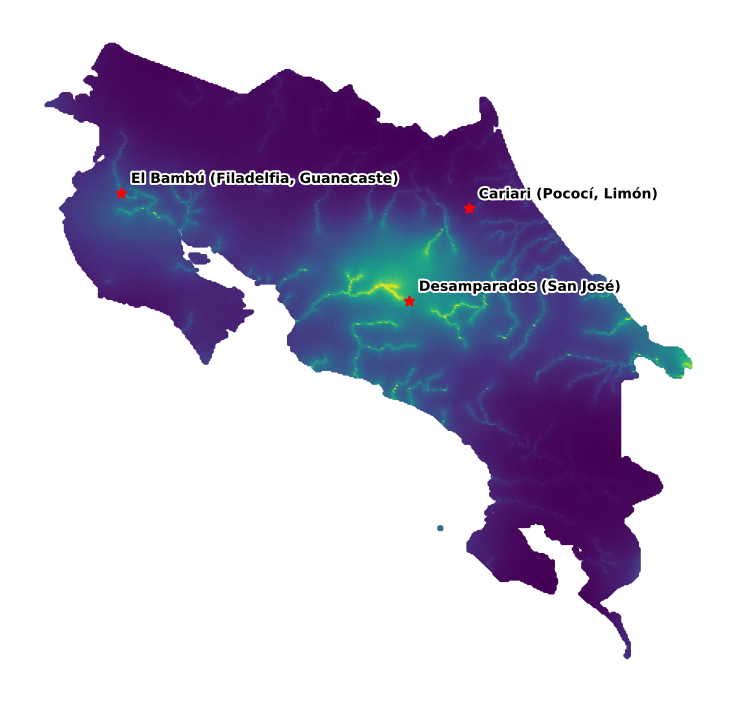

In [55]:
#Plot the predictions
import matplotlib.patheffects as path_effects
fig, ax = plt.subplots(1,1,figsize=(5, 5), dpi= 144 )
df_a.plot("norm",legend=False, ax=ax,markersize =1.5,vmax=0.01 )

locations_df.plot( c="r", marker='*', markersize=25, linestyle='-', ax=ax)
# laos_disasters_geo.plot(ax=ax[1], alpha = 0.3, c = "r", markersize =2, )

ax .set_xticks([])
ax .set_yticks([]);


# Add city names as labels with white border
for idx, row in locations_df.iterrows():
    ax.annotate(
        row.name,  # City name (assuming the index is the city name)
        (row["long"], row["lat"]),  # Coordinates for annotation
        textcoords="offset points",
        xytext=(5, 5),  # Offset for better visibility
        ha='left',
        fontsize=7,
        color='black',
        fontweight="bold",
        path_effects=[path_effects.withStroke(linewidth=2, foreground="white")]
    )
    
# fig.savefig("figures_and_plots/results/loc_cr_map.png",     bbox_inches="tight",   dpi=144);

In [56]:
# Load return years and damage curve
pd.options.display.float_format = "{:.4f}".format
damage_curve = pd.read_csv('data/curves_df_cr.csv')
return_years = pd.read_csv('data/return_years_cr.csv', index_col='return_years')

fila_prob = {}
damage_curve_desamp = pd.DataFrame()
return_years_desamp = pd.DataFrame(index = return_years.index)

for year in [2000, 2010, 2018, 2030, 2045]:
    fila_prob[year] = model_full_pred_country_gpd[year]['y_hat'].loc[best_loc_index['Desamparados (San José)'], :]['norm']
    damage_curve_desamp.loc[:, year] = damage_curve[str(year)] * fila_prob[year]
    return_years_desamp.loc[:, year] = return_years[str(year)] * fila_prob[year] 
    
damage_curve_desamp[['percentile', 'percentile_inv']] = damage_curve[['percentile', 'percentile_inv']]

In [57]:
places_prob = pd.DataFrame(index = best_loc_index.keys())
for year in [2000, 2010, 2018, 2030, 2045]:
    for place in list(best_loc_index.keys()) :
        places_prob.loc[place, year ] = model_full_pred_country_gpd[year]['y_hat'].loc[best_loc_index[place], :]['yhat_freq']

In [58]:
places_prob

,2000,2010,2018,2030,2045
Desamparados (San José),0.0034,0.0094,0.0065,0.0086,0.0105
"El Bambú (Filadelfia, Guanacaste)",0.0019,0.0048,0.0033,0.0050,0.0065
"Cariari (Pococí, Limón)",0.0006,0.0017,0.0012,0.0017,0.0027


In [59]:
# Load return years and damage curve
pd.options.display.float_format = "{:.4f}".format
damage_curve = pd.read_csv('data/curves_df_cr.csv')
return_years = pd.read_csv('data/return_years_cr.csv', index_col='return_years')

fila_prob = {}
damage_curve_fila = pd.DataFrame()
return_years_fila = pd.DataFrame(index = return_years.index)


for year in [2000, 2010, 2018, 2030, 2045]:
    places_prob.loc
    fila_prob[year] = model_full_pred_country_gpd[year]['y_hat'].loc[best_loc_index['El Bambú (Filadelfia, Guanacaste)'], :]['norm']
    damage_curve_fila.loc[:, year] = damage_curve[str(year)] * fila_prob[year]
    return_years_fila.loc[:, year] = return_years[str(year)] * fila_prob[year] 
    
# damage_curve_fila[['percentile', 'percentile_inv']] = damage_curve[['percentile', 'percentile_inv']]

In [60]:
curve_years =prediction_dates = [pd.to_datetime('2000-01-01 00:00:00'),
                    pd.to_datetime('2010-01-01 00:00:00'),
                    pd.to_datetime('2018-01-01 00:00:00'), 
                    pd.to_datetime('2030-01-01 00:00:00'),
                    pd.to_datetime('2045-01-01 00:00:00'),
                    pd.to_datetime('2055-01-01 00:00:00'),]

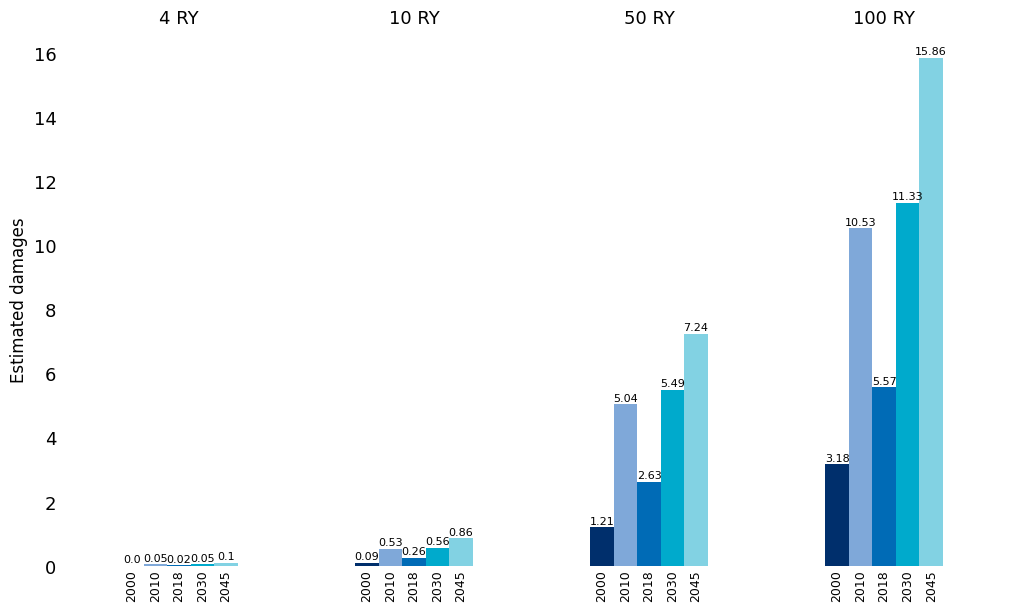

In [61]:
import matplotlib.pyplot as plt
import numpy as np
years_plot =  [2000, 2010, 2018, 2030, 2045]


fig, axes = plt.subplots(1, 1, figsize=(10, 6), sharex=True)

# Define the colormap
OECD_colors = ["#002F6C", "#7FA8D9", "#006BB6", "#00AACC", "#82D2E3"]

data_plot = return_years_fila.head(4).reset_index().sort_index(ascending = False).set_index('return_years')

# Sample more distinct colors from the colormap
# num_colors = data_plot.shape[1]
# colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]

# Plot the data with the modified colormap
bars =data_plot.plot(
    kind='bar',
    ax=axes,
    color=OECD_colors
)


# Add value labels with vertical separation
label_offset = 0.1  # Horizontal offset from the bar
vertical_offset = 0  # Vertical offset between labels

for bar_container in bars.containers:
    for i, bar in enumerate(bar_container):
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        y_pos = height + label_offset  # Adjust label_offset as needed
        axes.text(x_pos, y_pos, f'{str(height.round(2))}', fontsize=8, color='black', ha='center')


# Add year labels below each bar
for bar_container, year in zip(bars.containers, years_plot):
    for bar in bar_container:
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        y_pos = -label_offset  # Position below the bar
        axes.text(x_pos, y_pos, f'{year}', fontsize=9, color='black', ha='center', va='top', rotation = 90)


# Set the legend manually
handles, labels = axes.get_legend_handles_labels()
axes.get_legend().remove()

# Set axis labels
axes.set_ylabel('Estimated damages', fontsize=12)
axes.set_xlabel('')
axes.tick_params(axis='both', which='major', labelsize=13,length=0)
axes.set_xticklabels(axes.get_xticklabels(), rotation=0)
axes.xaxis.set_ticks_position('top')
axes.xaxis.set_label_position('top');

# fig.savefig(here('notebooks/final_paper/figures_and_plots/results') / 'filadelfia_return_years.png', format = 'png', bbox_inches='tight');